In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  13166.0 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 16 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Testing v1

In [4]:
f = jldopen("./data1.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klips = fmetadata.Klips_to_run

N = fmetadata.N
M = fmetadata.M
sN = fmetadata.sN
dx = fmetadata.L / sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

Klips

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 36, SciMLBase.ReturnCode.MaxIters => 28)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 49, SciMLBase.ReturnCode.Unstable => 14, SciMLBase.ReturnCode.MaxTime => 1)


8-element Vector{Tuple{Float64, Float64, Float64}}:
 (5.0, 1.0, 0.1)
 (11.0, 1.0, 0.1)
 (25.0, 1.0, 0.1)
 (5.0, 0.99, 0.1)
 (11.0, 0.99, 0.1)
 (25.0, 0.99, 0.1)
 (3.0, 0.7, 0.1)
 (3.0, 0.5, 0.1)

## Make run reports

In [7]:
make_v1_report(f, "./rep1/")

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 36, SciMLBase.ReturnCode.MaxIters => 28)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 49, SciMLBase.ReturnCode.Unstable => 14, SciMLBase.ReturnCode.MaxTime => 1)


## Inspect a single run

In [5]:
group_i = 3
run_i = 1

@show Klips[group_i]
K, li, p = Klips[group_i]

ps = fparams[run_i, group_i]
ode_fs = fode_fss[run_i, group_i]
sp_fs = fsp_fss[run_i, group_i];

maximum(ode_fs[1:N])

Klips[group_i] = (25.0, 1.0, 0.1)


10.152729076119993

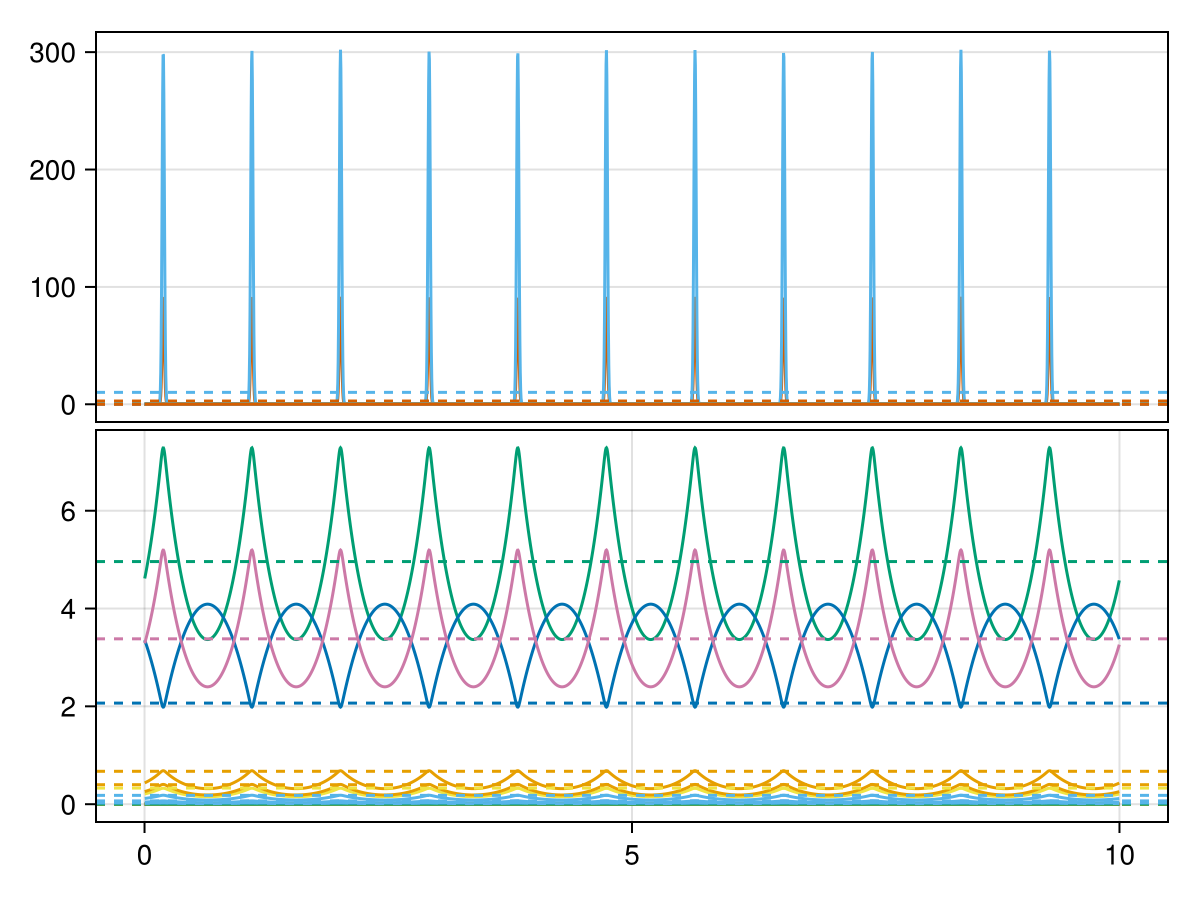

In [6]:
plot_spatial_fs(sp_fs, 20, fmetadata.sN, dx, ode_fs)

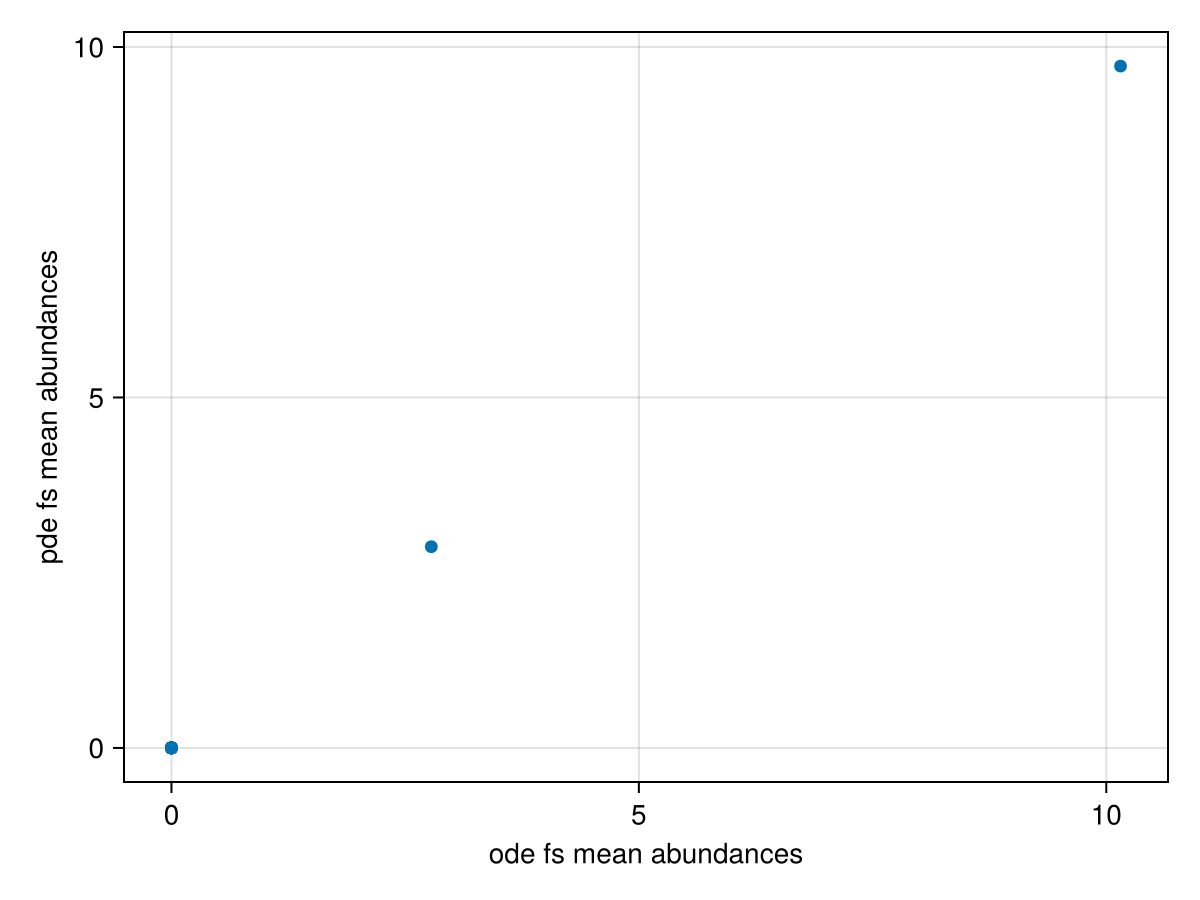

In [7]:
sp_means = mean(sp_fs, dims=2)[:,1]

scatter(ode_fs[1:N], sp_means[1:N];
    axis=(; xlabel="ode fs mean abundances", ylabel="pde fs mean abundances")
)

In [8]:
rel_abundances = Matrix{Float64}(undef, N, fmetadata.sN)
for i in axes(sp_fs, 2)
    strains_only = sp_fs[1:N, i]
    ss = sum(strains_only)
    rel_abundances[1:N, i] .= strains_only ./ ss
end

In [9]:
ss = sum(ode_fs[1:N])
ode_rel_abundances = ode_fs[1:N] ./ ss;

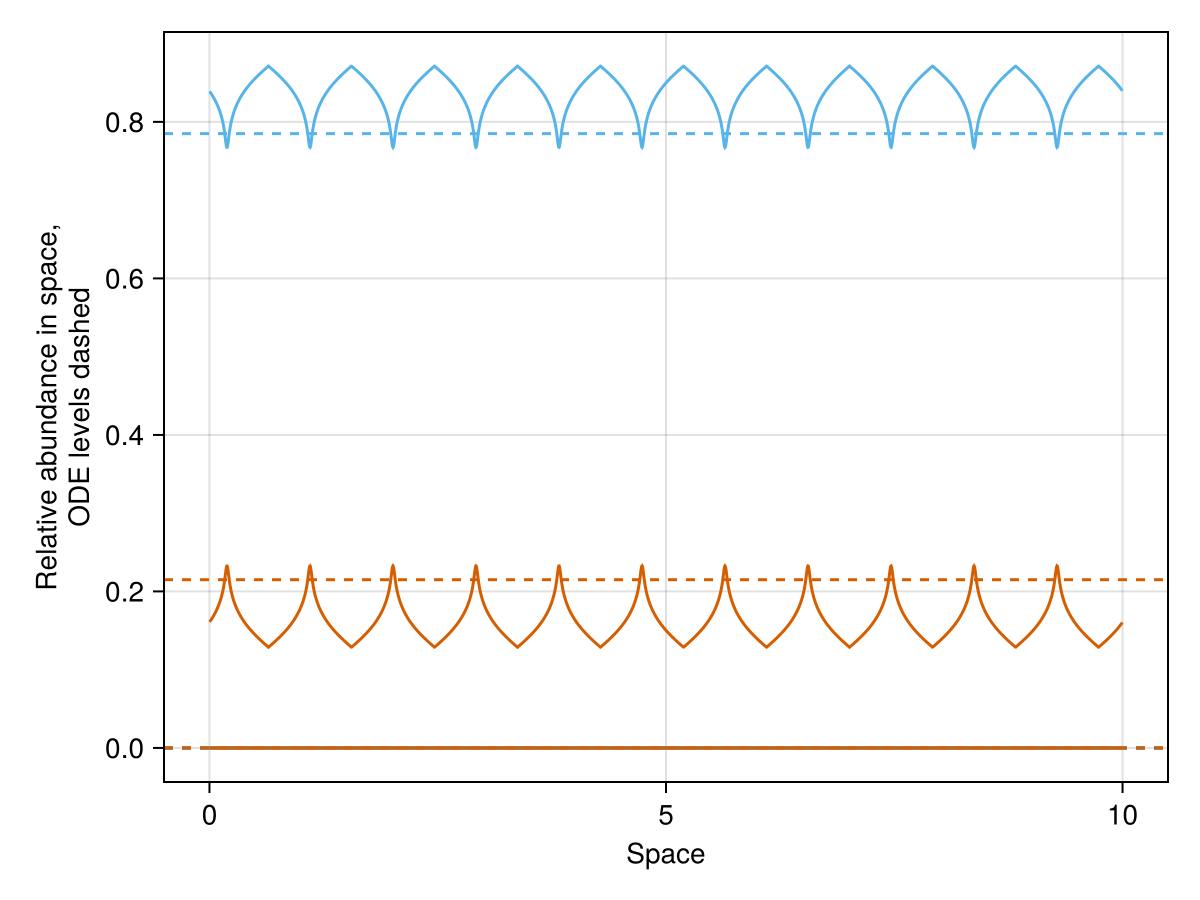

In [10]:
fig = Figure()
ax = Axis(fig[1,1];
    xlabel="Space",
    ylabel="Relative abundance in space,\nODE levels dashed"
)
spatial_xs = get_spatial_gridpoints_dx(fmetadata.sN, dx)
for i in 1:N
    lines!(ax, spatial_xs, rel_abundances[i, :]; color=Cycled(i))
    hlines!(ax, ode_rel_abundances[i]; linestyle=:dash, color=Cycled(i))
end
fig

In [11]:
eco_e_flow_out_ms = Vector{Float64}(undef, sN)
eco_e_flow_out_rs = Vector{Float64}(undef, sN)
for si in 1:sN
    xx = sp_fs[:, si]
    eco_e_flow_out_ms[si] = 0.
    for i in 1:N
        eco_e_flow_out_ms[si] += ps.m[i] * xx[i]
    end
    eco_e_flow_out_rs[si] = 0.
    for a in 1:M
        eco_e_flow_out_rs[si] += ps.r[a] * xx[N+a]
    end
end
eco_e_flow_out = eco_e_flow_out_ms .+ eco_e_flow_out_rs;

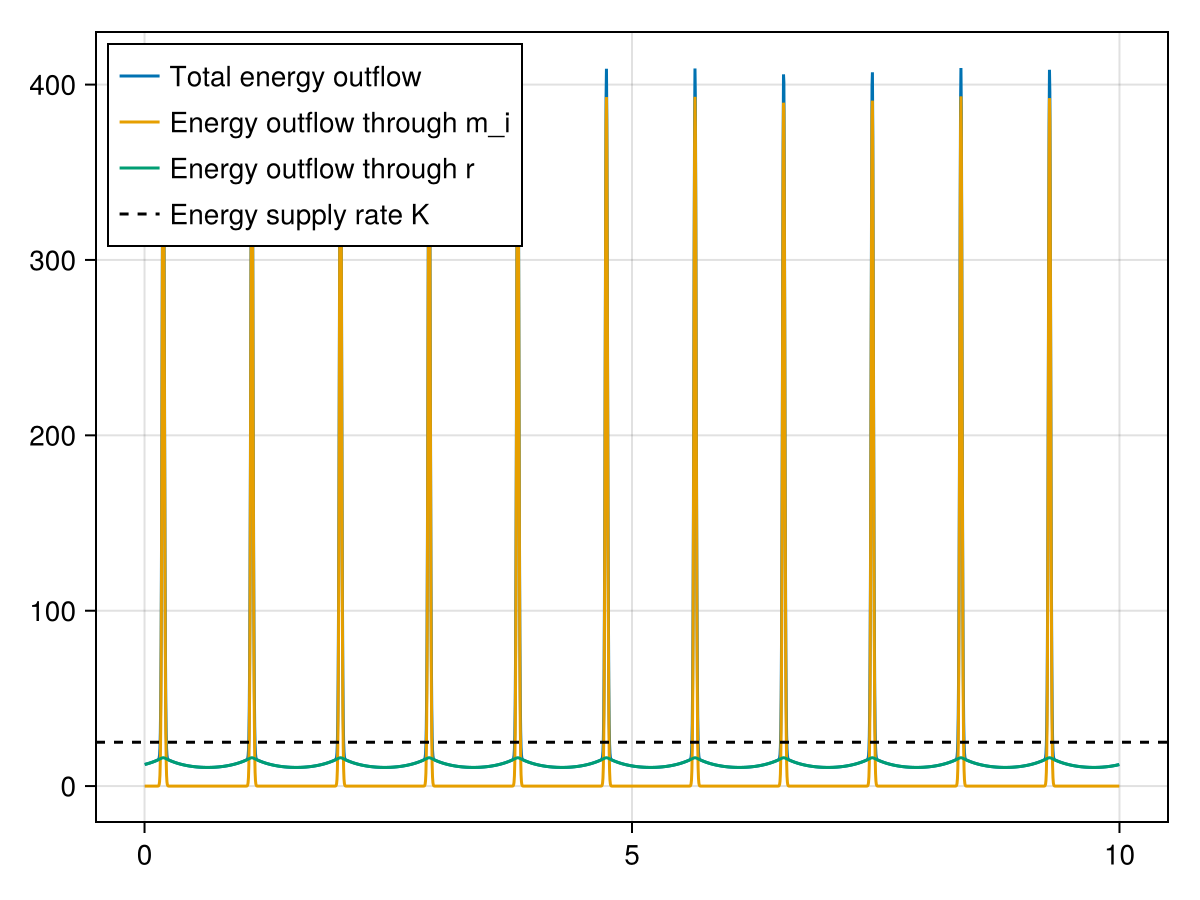

In [12]:
fig = Figure()
ax = Axis(fig[1,1])

lines!(ax, spatial_xs, eco_e_flow_out; label="Total energy outflow")
lines!(ax, spatial_xs, eco_e_flow_out_ms; label="Energy outflow through m_i")
lines!(ax, spatial_xs, eco_e_flow_out_rs; label="Energy outflow through r")

hlines!(ax, [K]; linestyle=:dash, label="Energy supply rate K", color=:black)
axislegend(ax; position=:lt)

Makie.save("../../../data/spatial_energy_flows.pdf", fig)

fig

In [13]:
influx_Ri = findall(!=(0), ps.K)[1]

16

In [14]:
xx = sum(ode_fs[N+1:end]) - ode_fs[N+influx_Ri]
xx / ode_fs[N+influx_Ri]

4.8460577308990755

In [15]:
xx = sum(sp_means[N+1:end]) - sp_means[N+influx_Ri]
xx / sp_means[N+influx_Ri]

2.6903001629518717

## Running things again

### ODEs

In [64]:
tps = change_bmmicrmparams(ps.mmicrm_params; usenthreads=nthreads())
tps = ps.mmicrm_params
ode_prob = make_mmicrm_problem(tps, copy(fmetadata.ode_u0), fmetadata.T;
    # usejac=false,
);

In [79]:
@time s = solve(ode_prob, QNDF();
    maxiters=100000,
    callback=make_timer_callback(1 * 60),
    abstol=1e-9,
    reltol=1e-9,
);

  0.013583 seconds (1.91 k allocations: 638.875 KiB)


In [46]:
@show mmicrmmaxresid(s.u[end], ps)
@show mmicrmmaxresid(ode_fs, ps);

mmicrmmaxresid(s.u[end], ps) = 1.1546319456101628e-14
mmicrmmaxresid(ode_fs, ps) = 6.217248937900877e-15


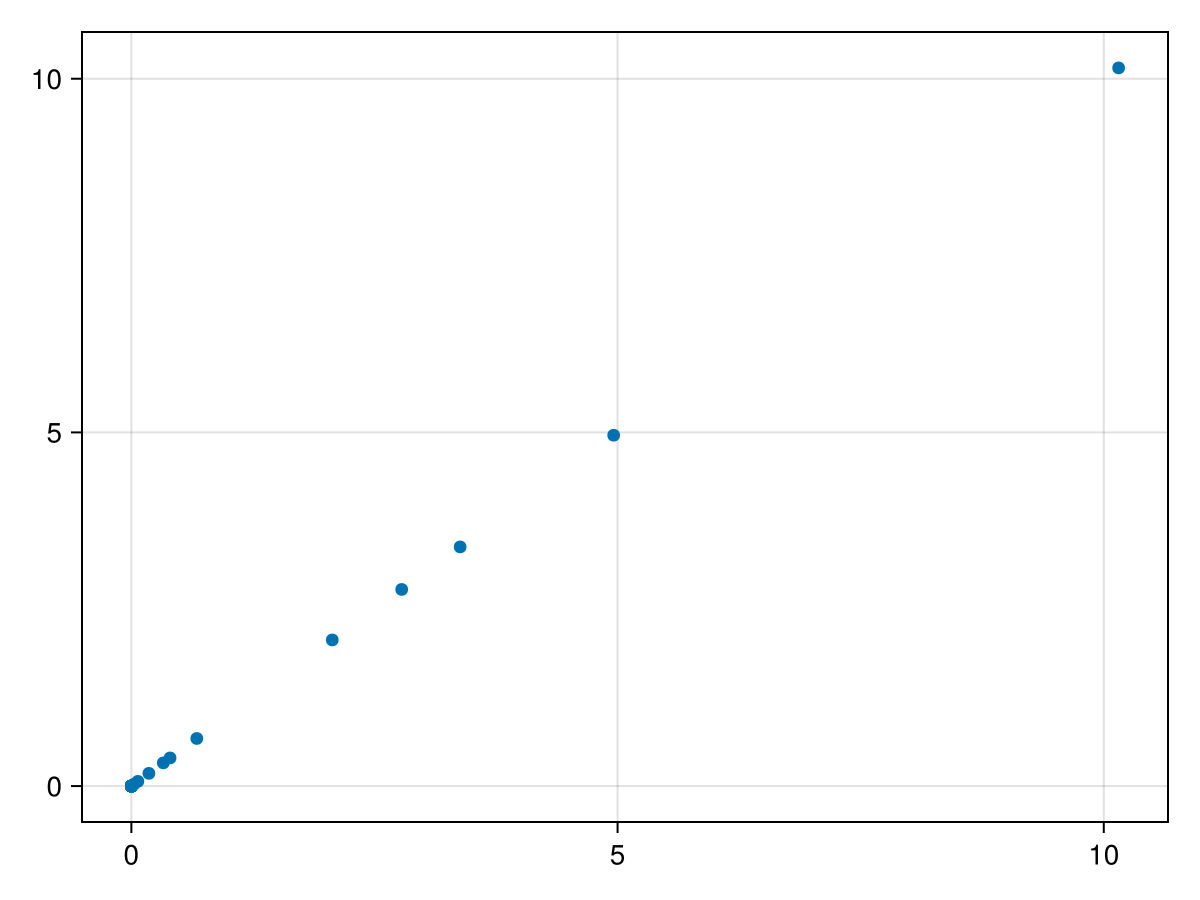

In [47]:
scatter(ode_fs, s.u[end])

### PDEs

In [250]:
empty!(Out)
GC.gc()

In [255]:
u0_ = expand_u0_to_size((sN,), ode_fs)
u0 = perturb_u0_uniform(N, M, u0_, fmetadata.sp_epsilon);

sps = BSMMiCRMParams(
    ps.mmicrm_params,
    ps.Ds,
    CartesianSpace{1,Tuple{Periodic}}(SA[dx]),
    nthreads(),
)
sp = make_smmicrm_problem(sps, u0, fmetadata.T;
    # jac_type=:sparse
    jac_type=:both
    # jac_type=:true
);

In [ ]:
tol = 1e5 * eps()

@time pde_s = solve(sp, QNDF();
    dense=false,
    save_everystep=false,
    calck=false,
    abstol=tol,
    reltol=tol,
    callback=make_timer_callback(10),
    # maxiters=5,
);

  4.105575 seconds (867.70 k allocations: 1.742 GiB, 1.67% gc time, 10.16% compilation time: 100% of which was recompilation)


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


In [254]:
@show smmicrmmaxresid(pde_s.u[end], pde_s.prob.p)
@show smmicrmmaxresid(sp_fs, pde_s.prob.p);

smmicrmmaxresid(pde_s.u[end], pde_s.prob.p) = 225.7634500110212
smmicrmmaxresid(sp_fs, pde_s.prob.p) = 1.1543477285158588e-10


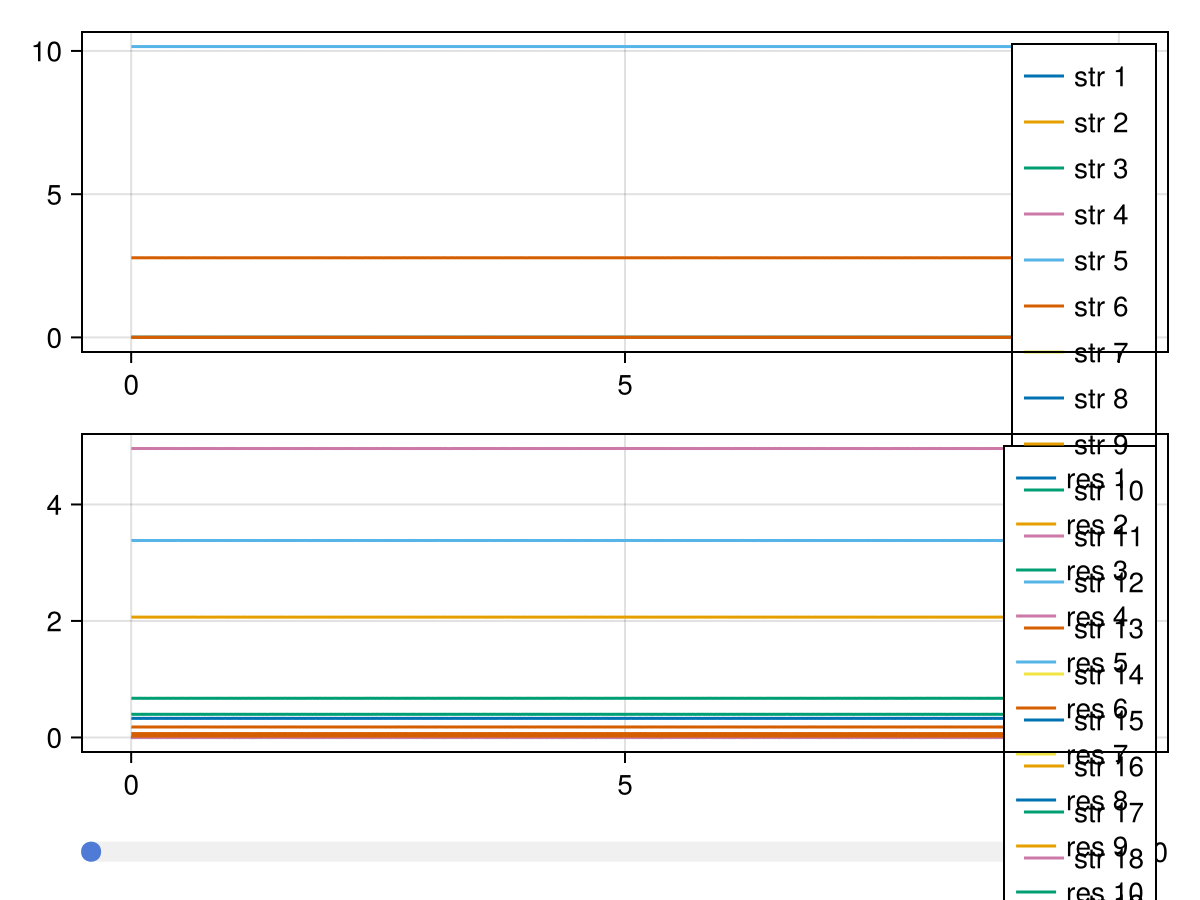

In [176]:
faa = plot_1dsmmicrm_sol_interactive(pde_s)
# display(GLMakie.Screen(), faa)
faa

In [249]:
ui = 1
si = 1

@show u0[ui, si] - u0[(si - 1) * 40 + ui]

u0[ui, si] - u0[(si - 1) * 40 + ui] = 0.0


0.0

## Graphs and energy flows

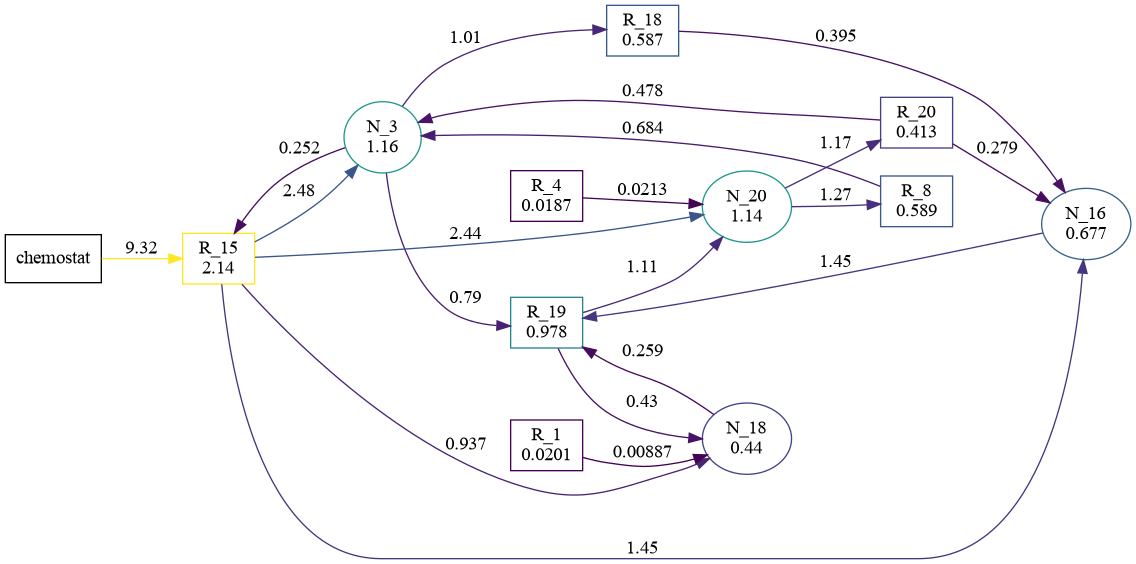

In [51]:
diagram_sfss_v3(ps, ode_fs;
    strain_threshold=0.1
)

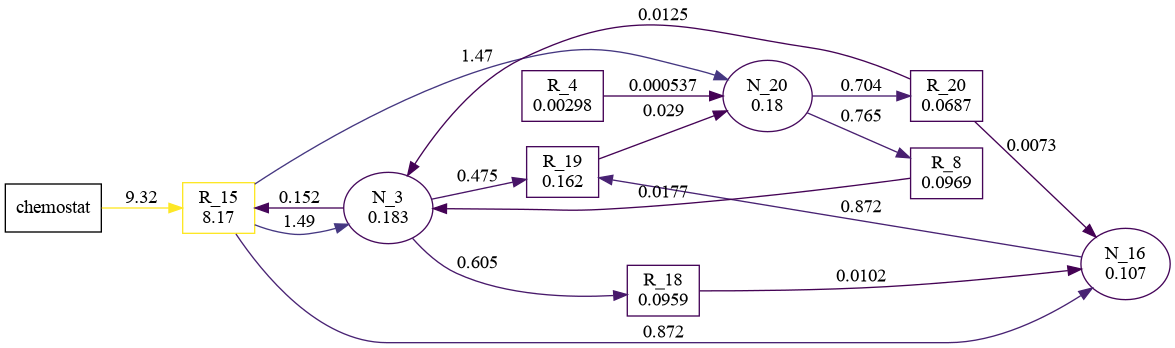

In [52]:
diagram_sfss_v3(ps, sp_means;
    strain_threshold=0.1
)

In [58]:
using SSMCMain.ModifiedMiCRM.GraphAnalysis
using GraphMakie

In [55]:
mg = make_eflowgraph_simple(ps, ode_fs)

Meta graph based on a Graphs.SimpleGraphs.SimpleDiGraph{Int64} with vertex labels of type FGNodeType, vertex metadata of type @NamedTuple{name::String, val::Float64, desc::String}, edge metadata of type Float64, graph metadata given by (Ns = 20, Nr = 20, ps = BSMMiCRMParams{Nothing, Nothing, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0007972409717225, 0.997896325543841, 1.0011578624448783, 1.0015518586871544, 1.0017402584518904, 1.0017218222476039, 1.001010610193711, 0.9989638366365935, 0.9997408486326855, 1.0004709072359166, 0.9977558406728994, 1.003827554610948, 1.0004161519382457, 1.001552253437825, 0.9993273915633695, 0.9951042853576142, 0.9981048585781157, 0.9976312242872495, 0.9997038353162093, 0.9946725633406263], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,